# Tracefold 过去 72 小时推送：交易 Agent 事件研究

## TL;DR

这是一份**描述性 shadow replay**，不是可泛化的策略回测，也不是投资建议。它用本机 Tracefold 的实际 `delivered` 新闻、公开分钟行情和原始披露回答三个问题：

1. 同一个催化剂被推送了多少次，是否应先合并为 episode；
2. 第一条推送时，事实是否已经由原始来源验证；
3. 若把推送时点当成信号，执行标的是否存在、价格是否已经反应。

安全边界：Notebook 只读取 `/api/news/*` 与公开行情；bootstrap token 只留在内存，不显示、不保存；不访问账户、不下单。

## 范围与数据定义

- 观察窗：执行时向 Tracefold 查询 `hours=72&outcome=pushed`；输出记录实际 UTC 截止时间。
- “已推送”：feed 的 `outcome.group=pushed`，并核对目标 Event 的 delivery 状态。
- episode：人工定义的研究集合；它**不改写** News storyline，也不把重复卡当成独立证据。
- 价格：MRVL/GOOGL/SKHY 使用 Binance USD-M TradFi 永续的公开 1 分钟 K 线；MRNA 使用 Yahoo Finance 的原生股票盘前 1 分钟序列，仅作为二级行情交叉检查。
- 时间规则：研究阶段只看推送时点及之前的信息；下面的 forward return 由独立 evaluator 计算，不能回流给研究 Agent。

In [1]:
from __future__ import annotations

import json
import urllib.parse
import urllib.request
from datetime import datetime, timezone
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

TRACEFOLD_BASE = "http://127.0.0.1:8765"
USER_AGENT = "Tracefold research event study/1.0"


def get_json(url: str, *, headers: dict[str, str] | None = None, data: bytes | None = None) -> Any:
    request = urllib.request.Request(url, headers=headers or {"User-Agent": USER_AGENT}, data=data)
    with urllib.request.urlopen(request, timeout=30) as response:
        return json.load(response)


def tracefold_token() -> str:
    # Secret is returned to the caller only; it is never printed or persisted.
    return get_json(f"{TRACEFOLD_BASE}/api/bootstrap")["data"]["ws_token"]


def tracefold_get(path: str, token: str) -> dict[str, Any]:
    return get_json(
        f"{TRACEFOLD_BASE}{path}",
        headers={"Authorization": f"Bearer {token}", "User-Agent": USER_AGENT},
    )["data"]


def fetch_pushed_feed(hours: int = 72) -> tuple[list[dict[str, Any]], dict[str, int]]:
    token = tracefold_token()
    events: list[dict[str, Any]] = []
    counts: dict[str, int] | None = None
    cursor: str | None = None
    while True:
        params: dict[str, Any] = {"hours": hours, "outcome": "pushed", "limit": 50}
        if cursor:
            params["cursor"] = cursor
        page = tracefold_get("/api/news/feed?" + urllib.parse.urlencode(params), token)
        events.extend(page["events"])
        counts = counts or page.get("counts")
        cursor = page.get("next_cursor")
        if not cursor:
            break
    return events, counts or {}


AS_OF_UTC = datetime.now(timezone.utc)
events, feed_counts = fetch_pushed_feed()
assert len(events) == feed_counts["pushed"], (len(events), feed_counts)

snapshot = pd.DataFrame(
    [
        {"as_of_utc": AS_OF_UTC.isoformat(), **feed_counts, "delivered_share_pct": 100 * feed_counts["pushed"] / feed_counts["total"]}
    ]
)
snapshot

,as_of_utc,total,pushed,held,pending,delivered_share_pct
0,2026-08-20T16:56:51.164133+00:00,3652,776,2876,0,21.248631


## Episode consolidation

以下 ID 是本次人工复核的研究集合。MRNA 集合刻意包含催化剂、价格回声、衍生品上线与隔日回撤；这些是一个因果 episode 的不同阶段，不是多份独立“置信度投票”。

,episode,curated_sent_events
0,MRVL–Google 协议/认股权证,7
1,SK hynix 回购/注销,8
2,MRNA Phase 3 声称及交易回声,14


,episode,first_event_id,first_opened_utc,first_settled_utc,first_source,storyline_key
0,MRVL–Google 协议/认股权证,ac84b9f91715,2026-08-19T12:26:31.562000+00:00,2026-08-19T12:26:36.815000+00:00,opennews,asset:MRVL
1,SK hynix 回购/注销,62a81cd18b9c,2026-08-19T06:41:39.669000+00:00,2026-08-19T06:41:53.469000+00:00,opennews,asset:SKHY
2,MRNA Phase 3 声称及交易回声,8c5021c9583f,2026-08-19T11:11:35.250000+00:00,2026-08-19T11:11:40.391000+00:00,the inner circle trading group dp david prince,macro:general


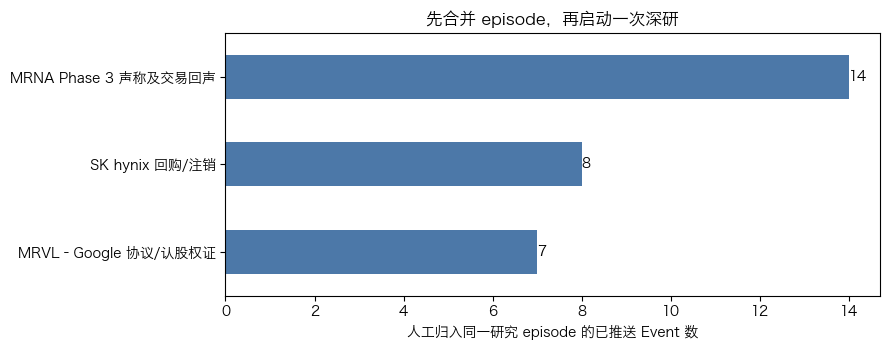

In [2]:
def title_text(event: dict[str, Any]) -> str:
    return (event.get("leader_title") or "").lower()


def is_mrvl_google(event: dict[str, Any]) -> bool:
    text = title_text(event)
    return ("marvell" in text and "google" in text) or ("迈威尔" in text and "谷歌" in text)


def is_skhynix_buyback(event: dict[str, Any]) -> bool:
    text = title_text(event)
    issuer = "hynix" in text or "海力士" in text
    action = any(word in text for word in ("buy back", "buyback", "repurchase", "treasury", "回购", "库存股"))
    return issuer and action


def is_mrna_episode(event: dict[str, Any]) -> bool:
    text = title_text(event)
    return "moderna" in text or "$mrna" in text or "mrna.o" in text or "$mrnausdt" in text


EPISODE_RULES = {
    "MRVL–Google 协议/认股权证": is_mrvl_google,
    "SK hynix 回购/注销": is_skhynix_buyback,
    "MRNA Phase 3 声称及交易回声": is_mrna_episode,
}

episode_rows = []
first_rows = []
for episode, predicate in EPISODE_RULES.items():
    selected = sorted((event for event in events if predicate(event)), key=lambda x: x["opened_at_ms"])
    episode_rows.append({"episode": episode, "curated_sent_events": len(selected)})
    if selected:
        first = selected[0]
        first_rows.append(
            {
                "episode": episode,
                "first_event_id": first["event_id"][:12],
                "first_opened_utc": datetime.fromtimestamp(first["opened_at_ms"] / 1000, timezone.utc).isoformat(),
                "first_settled_utc": datetime.fromtimestamp(first["delivery"]["settled_at_ms"] / 1000, timezone.utc).isoformat(),
                "first_source": first["reporting_origin"],
                "storyline_key": first["storyline_key"],
            }
        )

episode_df = pd.DataFrame(episode_rows)
first_df = pd.DataFrame(first_rows)
display(episode_df)
display(first_df)

ax = episode_df.plot.barh(x="episode", y="curated_sent_events", legend=False, color="#4c78a8", figsize=(9, 3.6))
ax.set_xlabel("人工归入同一研究 episode 的已推送 Event 数")
ax.set_ylabel("")
ax.set_title("先合并 episode，再启动一次深研")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 事实核验：模型 verdict 不是交易事实

MRVL 的核心条款可由 SEC 8‑K 原文确认；SK hynix 的回购/注销可由公司发布确认。MRNA 则相反：首条来源是社交媒体价格播报，ClinicalTrials.gov 在核验时仍显示试验进行中、无结果、预计 2029 年完成，而且已有 verdict 把“个性化癌症疫苗”误写成“流感疫苗”。

In [3]:
token = tracefold_token()
mrna_detail = tracefold_get(
    "/api/news/events/8c5021c9583fe9bc31d5e276dab5deffbef492af30d8c94e380958e120997d35",
    token,
)
quality_counterexample = pd.DataFrame(
    [
        {
            "field": "wire headline",
            "observed": mrna_detail["event"]["leader_title"],
        },
        {
            "field": "stored why_zh",
            "observed": mrna_detail["triage"]["why_zh"],
        },
        {
            "field": "official registry at review",
            "observed": "NCT05933577: Active, not recruiting; No Results Posted; estimated primary completion 2029-10-26",
        },
    ]
)
quality_counterexample

,field,observed
0,wire headline,$MRNA $MRK Moderna jumps 54% to $97.52 after P...
1,stored why_zh,流感疫苗三期数据达标直接验证商业化前景，默克作为合作方同步受益，生物科技板块情绪被点燃
2,official registry at review,"NCT05933577: Active, not recruiting; No Result..."


In [4]:
source_verification = pd.DataFrame(
    [
        {
            "episode": "MRVL–Google",
            "status": "confirmed",
            "primary_source": "SEC 8-K filed 2026-08-19",
            "finding": "Commercial agreement; 58,970,907-share warrant at $206.58; most vesting tied to $500m revenue tranches.",
            "url": "https://www.sec.gov/Archives/edgar/data/1835632/000119312526356217/d412696d8k.htm",
        },
        {
            "episode": "SK hynix buyback",
            "status": "confirmed",
            "primary_source": "Company release distributed by PR Newswire",
            "finding": "₩40tn repurchase and full cancellation; ~3.3% shares; Aug 20 start; about three months.",
            "url": "https://www.prnewswire.com/news-releases/sk-hynix-accelerates-40-trillion-won-share-repurchase-and-cancellation-program-pursues-shareholder-return-expansion-to-over-50-of-fcf-302855022.html",
        },
        {
            "episode": "MRNA INTerpath-001",
            "status": "conflict / unverified",
            "primary_source": "ClinicalTrials.gov NCT05933577",
            "finding": "Registry showed no posted results and estimated 2029 primary completion; no contemporaneous Moderna/Merck filing was found.",
            "url": "https://clinicaltrials.gov/study/NCT05933577",
        },
    ]
)
source_verification

,episode,status,primary_source,finding,url
0,MRVL–Google,confirmed,SEC 8-K filed 2026-08-19,"Commercial agreement; 58,970,907-share warrant...",https://www.sec.gov/Archives/edgar/data/183563...
1,SK hynix buyback,confirmed,Company release distributed by PR Newswire,₩40tn repurchase and full cancellation; ~3.3% ...,https://www.prnewswire.com/news-releases/sk-hy...
2,MRNA INTerpath-001,conflict / unverified,ClinicalTrials.gov NCT05933577,Registry showed no posted results and estimate...,https://clinicaltrials.gov/study/NCT05933577


## Point-in-time 价格反应

所有回报都从第一条推送后可见的第一根 1 分钟 close 起算；`pre_60m_pct` 衡量推送前一小时已经发生的变动。MRNA 的 `vs_previous_close_pct` 使用 Yahoo 元数据中的前收盘价。这个表只描述价格路径，不证明可成交、没有滑点，也不证明策略有统计优势。

In [5]:
def binance_klines(symbol: str, start_ms: int, end_ms: int) -> list[tuple[int, float]]:
    params = urllib.parse.urlencode(
        {"symbol": symbol, "interval": "1m", "startTime": start_ms, "endTime": end_ms, "limit": 1500}
    )
    rows = get_json(f"https://fapi.binance.com/fapi/v1/klines?{params}")
    return [(int(row[0]), float(row[4])) for row in rows]


def yahoo_chart(symbol: str, start_ms: int, end_ms: int) -> tuple[dict[str, Any], list[tuple[int, float]]]:
    params = urllib.parse.urlencode(
        {
            "period1": start_ms // 1000,
            "period2": end_ms // 1000,
            "interval": "1m",
            "includePrePost": "true",
            "events": "div,splits",
        }
    )
    result = get_json(
        f"https://query2.finance.yahoo.com/v8/finance/chart/{urllib.parse.quote(symbol)}?{params}",
        headers={"User-Agent": USER_AGENT},
    )["chart"]["result"][0]
    timestamps = result.get("timestamp", [])
    closes = result["indicators"]["quote"][0]["close"]
    points = [(timestamp * 1000, float(close)) for timestamp, close in zip(timestamps, closes) if close is not None]
    return result["meta"], points


def first_at_or_after(points: list[tuple[int, float]], timestamp_ms: int) -> tuple[int, float]:
    return next((point for point in points if point[0] >= timestamp_ms), (0, float("nan")))


def event_metrics(points: list[tuple[int, float]], event_ms: int, previous_close: float | None = None) -> dict[str, float]:
    _, entry = first_at_or_after(points, event_ms)
    _, pre_60 = first_at_or_after(points, event_ms - 60 * 60_000)
    result: dict[str, float] = {
        "entry_price": entry,
        "pre_60m_pct": 100 * (entry / pre_60 - 1),
    }
    if previous_close:
        result["vs_previous_close_pct"] = 100 * (entry / previous_close - 1)
    for minutes in (5, 30, 60, 120):
        _, price = first_at_or_after(points, event_ms + minutes * 60_000)
        result[f"fwd_{minutes}m_pct"] = 100 * (price / entry - 1)
    _, exit_120 = first_at_or_after(points, event_ms + 120 * 60_000)
    for delay in (0, 5, 30):
        _, delayed_entry = first_at_or_after(points, event_ms + delay * 60_000)
        result[f"delay_{delay}m_to_120m_pct"] = 100 * (exit_120 / delayed_entry - 1)
    return result


EVENT_TIMES = {
    "MRVLUSDT": 1787142391562,
    "GOOGLUSDT": 1787142391562,
    "SKHYUSDT": 1787121699669,
    "MRNA": 1787137895250,
}

market_rows = []
for symbol in ("MRVLUSDT", "GOOGLUSDT", "SKHYUSDT"):
    event_ms = EVENT_TIMES[symbol]
    points = binance_klines(symbol, event_ms - 60 * 60_000, event_ms + 8 * 60 * 60_000)
    market_rows.append({"instrument": symbol, "source": "Binance USD-M public klines", **event_metrics(points, event_ms)})

mrna_ms = EVENT_TIMES["MRNA"]
mrna_meta, mrna_points = yahoo_chart("MRNA", mrna_ms - 24 * 60 * 60_000, mrna_ms + 24 * 60 * 60_000)
market_rows.append(
    {
        "instrument": "MRNA native equity",
        "source": "Yahoo Finance chart (secondary)",
        **event_metrics(mrna_points, mrna_ms, previous_close=float(mrna_meta["chartPreviousClose"])),
    }
)

market_df = pd.DataFrame(market_rows)
market_df.round(2)

,instrument,source,entry_price,pre_60m_pct,fwd_5m_pct,fwd_30m_pct,fwd_60m_pct,fwd_120m_pct,delay_0m_to_120m_pct,delay_5m_to_120m_pct,delay_30m_to_120m_pct,vs_previous_close_pct
0,MRVLUSDT,Binance USD-M public klines,226.49,6.09,4.00,7.69,6.77,2.30,2.30,-1.64,-5.01,NaN
1,GOOGLUSDT,Binance USD-M public klines,342.39,-0.17,0.04,0.25,0.12,0.42,0.42,0.38,0.17,NaN
2,SKHYUSDT,Binance USD-M public klines,153.03,0.70,3.18,5.46,6.10,8.01,8.01,4.68,2.42,NaN
3,MRNA native equity,Yahoo Finance chart (secondary),95.12,50.95,4.98,13.36,26.47,27.73,27.73,21.67,12.67,47.56


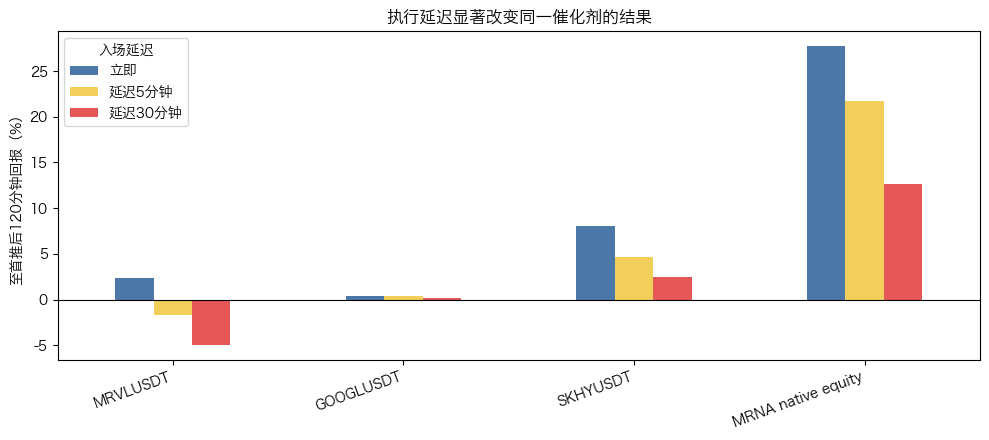

In [6]:
delay_cols = ["delay_0m_to_120m_pct", "delay_5m_to_120m_pct", "delay_30m_to_120m_pct"]
delay_plot = market_df.set_index("instrument")[delay_cols].rename(
    columns={
        "delay_0m_to_120m_pct": "立即",
        "delay_5m_to_120m_pct": "延迟5分钟",
        "delay_30m_to_120m_pct": "延迟30分钟",
    }
)
ax = delay_plot.plot.bar(figsize=(10, 4.5), color=["#4c78a8", "#f2cf5b", "#e45756"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("至首推后120分钟回报（%）")
ax.set_xlabel("")
ax.set_title("执行延迟显著改变同一催化剂的结果")
ax.legend(title="入场延迟")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## MRNA 的执行可用性反例

首条 MRNA 卡在 11:11 UTC；Hyperliquid 的 `xyz:MRNA` 第一根公开分钟 candle 出现在该卡之后，而且 News 随后才推送“上线/永续合约”事件。今天能在 OpenTrade discovery 找到 MRNA 合约，不能反推它在历史触发时已经可交易。

In [7]:
def hyperliquid_candles(coin: str, start_ms: int, end_ms: int) -> list[dict[str, Any]]:
    payload = json.dumps(
        {"type": "candleSnapshot", "req": {"coin": coin, "interval": "1m", "startTime": start_ms, "endTime": end_ms}}
    ).encode()
    return get_json(
        "https://api.hyperliquid.xyz/info",
        headers={"Content-Type": "application/json", "User-Agent": USER_AGENT},
        data=payload,
    )


hl_mrna = hyperliquid_candles("xyz:MRNA", mrna_ms - 60 * 60_000, mrna_ms + 8 * 60 * 60_000)
first_hl_ms = min((int(candle["t"]) for candle in hl_mrna), default=0)
tradeability_check = pd.DataFrame(
    [
        {
            "first_news_utc": datetime.fromtimestamp(mrna_ms / 1000, timezone.utc).isoformat(),
            "first_hyperliquid_candle_utc": datetime.fromtimestamp(first_hl_ms / 1000, timezone.utc).isoformat() if first_hl_ms else None,
            "lag_minutes": (first_hl_ms - mrna_ms) / 60_000 if first_hl_ms else None,
            "conclusion": "current availability cannot be back-projected; no OpenTrade instrument proven at trigger",
        }
    ]
)
tradeability_check

,first_news_utc,first_hyperliquid_candle_utc,lag_minutes,conclusion
0,2026-08-19T11:11:35.250000+00:00,2026-08-19T13:42:00+00:00,150.4125,current availability cannot be back-projected;...


## 决策含义

| Episode | Shadow 结论 | 原因 |
|---|---|---|
| MRVL–Google | `candidate / wait-for-condition` | SEC 原始披露确认；MRVL 永续在首推前后一小时有 candle，但首推前 60 分钟已明显上涨，5–30 分钟延迟后收益路径反转。先做流动性、价差、basis 与相对价值条件，不追 headline。 |
| SK hynix | `watch` | 公司材料确认；现金股已收盘，TradFi perp 的即时上涨伴随现金市场闭市 basis 风险；次日又出现员工股票奖励的 progression。 |
| MRNA | `no_trade` | 原始来源未核验、官方登记冲突、Triage 事实错误、首推时相对前收已暴涨，且历史触发时没有被证明存在可执行 OpenTrade 合约。 |

这三例只说明架构应该怎样防错，**不构成正期望策略证据**。下一步需要积累至少数百个 point-in-time episode，并加入 benchmark、spread、funding、fee、slippage、停牌/时段、失败成交和幸存者偏差。

## 来源与局限

- Tracefold 本机 News API：`/api/news/feed`、`/api/news/events/{event_id}`；快照时点见首表。
- [Marvell 2026-08-19 SEC 8-K](https://www.sec.gov/Archives/edgar/data/1835632/000119312526356217/d412696d8k.htm)
- [SK hynix 公司发布（PR Newswire 分发）](https://www.prnewswire.com/news-releases/sk-hynix-accelerates-40-trillion-won-share-repurchase-and-cancellation-program-pursues-shareholder-return-expansion-to-over-50-of-fcf-302855022.html)
- [ClinicalTrials.gov NCT05933577](https://clinicaltrials.gov/study/NCT05933577)
- [Binance USD-M Futures public REST](https://developers.binance.com/docs/derivatives/usds-margined-futures/market-data/rest-api/Kline-Candlestick-Data)
- [Hyperliquid Info endpoint](https://hyperliquid.gitbook.io/hyperliquid-docs/for-developers/api/info-endpoint)
- Yahoo Finance chart 为二级、非官方研究接口；仅用于交叉检查 MRNA 原生股票盘前价格。

局限：人工 episode 标签、三个案例、短 forward window、未建订单簿与费用模型；OpenTrade 当前 capability discovery 不能证明历史时点 capability。